# Skenario 1 LSTM + TF-IDF (Split 80/20)

| Parameter | Detail |
|-----------|--------|
| **Algoritma** | LSTM |
| **Ekstraksi Fitur** | TF-IDF + Sequence Encoding |
| **Pembagian Data** | 80% Train / 20% Test |

## Setup & Load

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import numpy as np, pandas as pd, os, json, pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, BatchNormalization

tf.random.set_seed(42)
np.random.seed(42)
os.makedirs('models/scheme1', exist_ok=True)
os.makedirs('reports', exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
df = pd.read_csv('data/processed_data.csv')
print(f"Data dimuat: {len(df):,} sampel")

X = df['cleaned_text'].astype(str).values
y = df['label'].values

LABEL_NAMES = ['Negatif', 'Netral', 'Positif']
print(f"Distribusi kelas:")
for i, name in enumerate(LABEL_NAMES):
    print(f"   {name}: {(y == i).sum():,}")

Data dimuat: 15,000 sampel
Distribusi kelas:
   Negatif: 5,000
   Netral: 5,000
   Positif: 5,000


## Splitting

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Pembagian Data:")
print(f"Train    : {len(X_train):}")
print(f"Validasi : {len(X_val):}")
print(f"Test     : {len(X_test):}")

Pembagian Data:
Train : 12000
Validasi   : 1500
Test  : 1500


## Ekstrasi Fitur

In [5]:
MAX_FEATURES = 6000
MAX_SEQ_LEN  = 100
EMBED_DIM    = 128

tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1,2),
                        min_df=2, sublinear_tf=True)
tfidf.fit(X_train)
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_lstm = pad_sequences(tokenizer.texts_to_sequences(X_train),
                              maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val_lstm   = pad_sequences(tokenizer.texts_to_sequences(X_val),
                              maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_lstm  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                              maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat   = to_categorical(y_val,   num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

print(f"TF-IDF shape train : {X_train_lstm.shape}")
print(f"TF-IDF shape test  : {X_test_lstm.shape}")
print(f"Vocabulary size    : {len(tokenizer.word_index):,}")

TF-IDF shape train : (12000, 100)
TF-IDF shape test  : (1500, 100)
Vocabulary size    : 7,115


In [6]:
with open('models/scheme1/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [7]:
def build_lstm_model(input_shape, num_classes=3):
    model = Sequential([
        Embedding(MAX_FEATURES + 1, EMBED_DIM,
                  input_length=MAX_SEQ_LEN, name='Embedding'),
        SpatialDropout1D(0.4),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(LSTM(32, return_sequences=False)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='LSTM_TF-IDF')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(input_shape=(MAX_SEQ_LEN, EMBED_DIM))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_TF-IDF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [8]:
EPOCHS     = 50
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/scheme1/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_lstm, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_val_lstm, y_val_cat),
    callbacks=callbacks, verbose=1
)
print("Training selesai!")

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.5602 - loss: 1.0057 - val_accuracy: 0.6340 - val_loss: 0.8057 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7828 - loss: 0.5685 - val_accuracy: 0.8347 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8485 - loss: 0.4220 - val_accuracy: 0.8253 - val_loss: 0.4971 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8775 - loss: 0.3503 - val_accuracy: 0.8353 - val_loss: 0.5043 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8947 - loss: 0.3068 - val_accuracy: 0.8433 - val_loss: 0.4674 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9093 - loss: 0.2710 - val_accuracy: 0.8573 - val_loss: 0.4740 - learning_rate: 0.0010
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9170 - loss

## Evaluasi

In [9]:
# EVALUASI
model = load_model('models/scheme1/best_model.keras')

y_pred_prob = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test
train_loss, train_acc = model.evaluate(X_train_lstm, y_train_cat, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_lstm,  y_test_cat,  verbose=0)

print(f"HASIL EVALUASI")
print(f"Training Accuracy : {train_acc*100:.2f}%")
print(f"Testing  Accuracy : {test_acc*100:.2f}%")
print(f"F1-Score (macro)  : {f1_score(y_true, y_pred, average='macro')*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
HASIL EVALUASI
Training Accuracy : 97.50%
Testing  Accuracy : 86.00%
F1-Score (macro)  : 85.85%
              precision    recall  f1-score   support

     Negatif       0.83      0.79      0.81       500
      Netral       0.92      0.98      0.95       500
     Positif       0.82      0.81      0.82       500

    accuracy                           0.86      1500
   macro avg       0.86      0.86      0.86      1500
weighted avg       0.86      0.86      0.86      1500



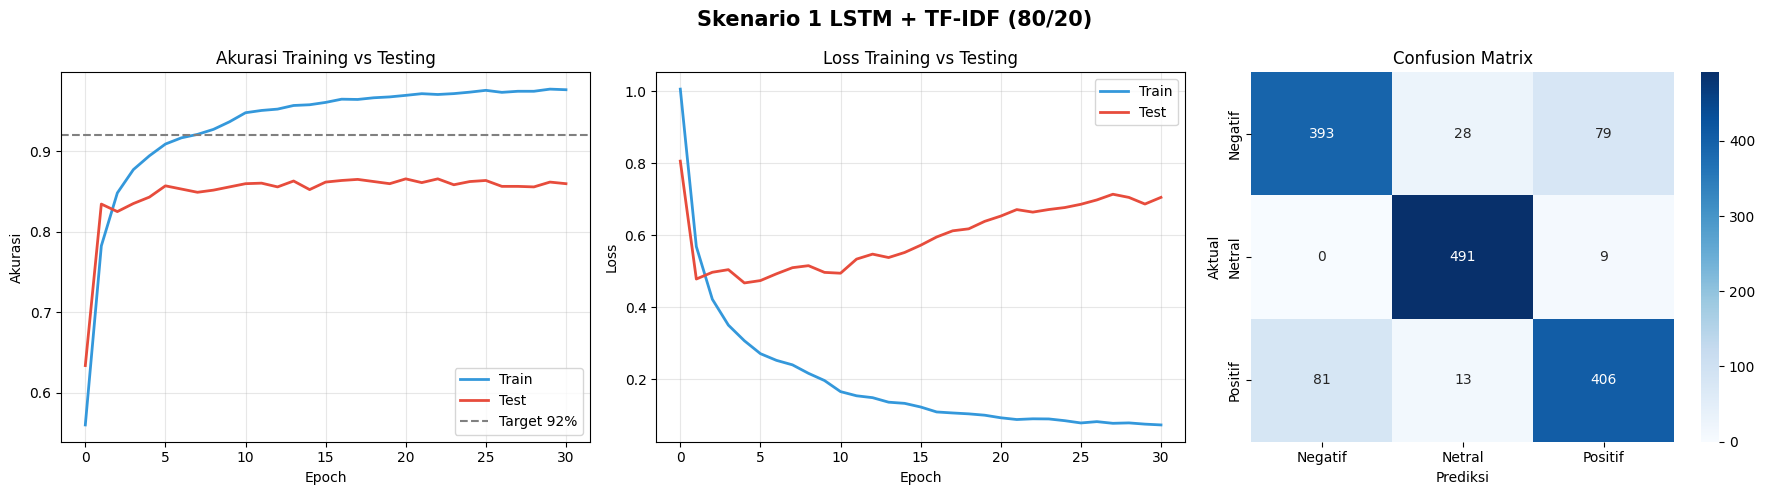

In [10]:
# VISUALISASI HASIL
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Skenario 1 LSTM + TF-IDF (80/20)', fontsize=15, fontweight='bold')

# Akurasi
axes[0].plot(history.history['accuracy'],     label='Train', color='#3498db', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Test',  color='#e74c3c', lw=2)
axes[0].axhline(0.92, color='gray', linestyle='--', label='Target 92%')
axes[0].set_title('Akurasi Training vs Testing')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Akurasi')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='#3498db', lw=2)
axes[1].plot(history.history['val_loss'], label='Test',  color='#e74c3c', lw=2)
axes[1].set_title('Loss Training vs Testing')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Aktual'); axes[2].set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

In [11]:
results_s1 = {
    'scheme': 'Skema 1',
    'algorithm': 'LSTM',
    'feature': 'TF-IDF',
    'split': '80/20',
    'train_acc': round(train_acc * 100, 2),
    'test_acc':  round(test_acc  * 100, 2),
    'f1_macro':  round(f1_score(y_true, y_pred, average='macro') * 100, 2)
}
with open('reports/scheme1_results.json', 'w') as f:
    json.dump(results_s1, f, indent=2)